## Importation des librairies

In [384]:
import pandapower as pp
import pandas as pd
import numpy as np

import pp_heig_simulation as pp_sim
import pp_heig_plot as pp_plot
from datetime import time

import matplotlib.pyplot as plt





## Récuperation du fichier pickle

In [385]:
net_pickle = pp.from_pickle('input-data/trey_net_student.p')

net_pickle.bus # Affiche les informations des bus, un slack et 11 PQ (charges)


,name,type,zone,in_service
0,STMT003438,PQ,Trafo,True
1,CDBT004764,PQ,North,True
2,CDBT003746,PQ,North,True
3,CDBT004760,PQ,North,True
4,CDBT012139,PQ,North,True
5,CDBT900784,PQ,North,True
6,CDBT901452,PQ,South,True
7,CDBT004774,PQ,South,True
8,CDBT901604,PQ,South,True
9,CDBT016055,PQ,South,True


In [386]:
net_pickle.line

,name,from_bus,to_bus,g_us_per_km,df,std_type,in_service
0,GKN3x150_150,0,1,0.0,1.0,None,True
1,GKN3x150_150_2,1,2,0.0,1.0,None,True
2,GKN3X95_95,1,3,0.0,1.0,None,True
3,GKT3X50_50,3,4,0.0,1.0,None,True
4,GKT3X50_50_2,4,5,0.0,1.0,None,True
5,GKN3x150_150_3,0,6,0.0,1.0,None,True
6,GKN3X95_95_2,6,7,0.0,1.0,None,True
7,GKN3x150_150_4,7,8,0.0,1.0,None,True
8,GKN3X50_50,7,9,0.0,1.0,None,True
9,GKN3X50_50_2,6,10,0.0,1.0,None,True


In [387]:
net_pickle.line.loc[:, "length_km"] = [0.18, 0.1, 0.115, 0.08, 0.09, 0.135, 0.1, 0.205, 0.085, 0.255, 0.340]
net_pickle.line.loc[:, "r_ohm_per_km"] = [0.124, 0.124, 0.193, 0.387, 0.387, 0.124, 0.193, 0.124, 0.387, 0.387, 0.0754]
net_pickle.line.loc[:, "x_ohm_per_km"] = [0.07] * 11
net_pickle.line.loc[:, "c_nf_per_km"] = [349, 349, 338, 298, 298, 349, 338, 349, 298, 298, 346]
net_pickle.line.loc[:, "max_i_ka"] = [0.4, 0.4, 0.252, 0.170, 0.170, 0.4, 0.252, 0.4, 0.170, 0.170, 0.512]
net_pickle.line.loc[:, "parallel"] = [1] * 11


In [388]:
net_pickle.line

,name,from_bus,to_bus,g_us_per_km,df,std_type,in_service,length_km,r_ohm_per_km,x_ohm_per_km,c_nf_per_km,max_i_ka,parallel
0,GKN3x150_150,0,1,0.0,1.0,None,True,0.180,0.1240,0.07,349,0.400,1
1,GKN3x150_150_2,1,2,0.0,1.0,None,True,0.100,0.1240,0.07,349,0.400,1
2,GKN3X95_95,1,3,0.0,1.0,None,True,0.115,0.1930,0.07,338,0.252,1
3,GKT3X50_50,3,4,0.0,1.0,None,True,0.080,0.3870,0.07,298,0.170,1
4,GKT3X50_50_2,4,5,0.0,1.0,None,True,0.090,0.3870,0.07,298,0.170,1
5,GKN3x150_150_3,0,6,0.0,1.0,None,True,0.135,0.1240,0.07,349,0.400,1
6,GKN3X95_95_2,6,7,0.0,1.0,None,True,0.100,0.1930,0.07,338,0.252,1
7,GKN3x150_150_4,7,8,0.0,1.0,None,True,0.205,0.1240,0.07,349,0.400,1
8,GKN3X50_50,7,9,0.0,1.0,None,True,0.085,0.3870,0.07,298,0.170,1
9,GKN3X50_50_2,6,10,0.0,1.0,None,True,0.255,0.3870,0.07,298,0.170,1


In [389]:
net_pickle.trafo # Affiche les informations des transformateurs, ici un seul transformateur

,name,hv_bus,lv_bus,sn_mva,vn_hv_kv,vn_lv_kv,vk_percent,vkr_percent,pfe_kw,i0_percent,vector_group,vk0_percent,vkr0_percent,mag0_percent,mag0_rx,si0_hv_partial,shift_degree,tap_side,tap_neutral,tap_min,tap_max,tap_step_percent,tap_step_degree,tap_pos,tap_phase_shifter,parallel,std_type,df,in_service
0,STMT003438,12,0,0.63,18.3,0.42,4.0,0.42,0.65,1.8,Dyn,3.0,0.75,0.3,1.9,1.9,0.0,lv,0,-3,3,2.0,0.0,-3,False,1,None,1.0,True


In [390]:
net_pickle.bus.loc[:, "vn_kv"] = [0.42] * 12 + [18.3]
net_pickle.bus

,name,type,zone,in_service,vn_kv
0,STMT003438,PQ,Trafo,True,0.42
1,CDBT004764,PQ,North,True,0.42
2,CDBT003746,PQ,North,True,0.42
3,CDBT004760,PQ,North,True,0.42
4,CDBT012139,PQ,North,True,0.42
5,CDBT900784,PQ,North,True,0.42
6,CDBT901452,PQ,South,True,0.42
7,CDBT004774,PQ,South,True,0.42
8,CDBT901604,PQ,South,True,0.42
9,CDBT016055,PQ,South,True,0.42


In [391]:
# Dans un foyer typique, la consommation électrique moyen est d'envrion 5000 kwH par an, ce qui équivaut 
# à une puissance active moyenne de 570 W par foyer. un foyer possédant principalement des charges résistives, le cosφ est proche de 1 
# et donc la puissance réactive est négligeable.
P_load_mean = 0.00057
Q_load_mean = 0.0

P_CDBT004764 = P_load_mean * 8
P_STMT003438 = P_CDBT901452 = P_load_mean * 5
P_CDBT900784 = P_CDBT012139 = P_CDBT004760 = P_CDBT004774 = P_CDBT016055 = P_load_mean * 4
P_CDBT003746 = P_load_mean * 3
N1 = P_60437 = P_CDBT901604 = P_load_mean

p_list = [
    P_STMT003438, P_CDBT004764, P_CDBT003746, P_CDBT004760,
    P_CDBT012139, P_CDBT900784, P_CDBT901452, P_CDBT004774,
    P_CDBT901604, P_CDBT016055, N1, P_60437
]

net_pickle.load.loc[:, "p_mw"] = p_list
net_pickle.load.loc[:, "q_mvar"] = [Q_load_mean] * len(net_pickle.load)

if "scaling" in net_pickle.load.columns:
    net_pickle.load.loc[:, "scaling"] = 1.0
else:
    net_pickle.load.insert(len(net_pickle.load.columns), "scaling", 1.0)
net_pickle.load

,name,bus,const_z_percent,const_i_percent,sn_mva,in_service,type,p_mw,q_mvar,scaling
0,STMT003438,0,0.0,0.0,None,True,wye,0.00285,0.0,1.0
1,CDBT004764,1,0.0,0.0,None,True,wye,0.00456,0.0,1.0
2,CDBT003746,2,0.0,0.0,None,True,wye,0.00171,0.0,1.0
3,CDBT004760,3,0.0,0.0,None,True,wye,0.00228,0.0,1.0
4,CDBT012139,4,0.0,0.0,None,True,wye,0.00228,0.0,1.0
5,CDBT900784,5,0.0,0.0,None,True,wye,0.00228,0.0,1.0
6,CDBT901452,6,0.0,0.0,None,True,wye,0.00285,0.0,1.0
7,CDBT004774,7,0.0,0.0,None,True,wye,0.00228,0.0,1.0
8,CDBT901604,8,0.0,0.0,None,True,wye,0.00057,0.0,1.0
9,CDBT016055,9,0.0,0.0,None,True,wye,0.00228,0.0,1.0


In [392]:
net_pickle.ext_grid.loc[net_pickle.ext_grid.index[0], "bus"] = 12
net_pickle.ext_grid.loc[net_pickle.ext_grid.index[0], "in_service"] = True
net_pickle.ext_grid["bus"] = net_pickle.ext_grid["bus"].astype("int64")


In [393]:

pp_plot.plot_power_network(
    net=net_pickle,
    plot_title="Configuration du réseau électrique",
    filename="custom_power_network.png",
)

In [394]:
pp.runpp(net_pickle)
pd.DataFrame(net_pickle._ppc["internal"]["Ybus"].toarray()).round(1)
pp_plot.plot_powerflow_result(
    net=net_pickle,
    plot_title="Vérification de l'implémentation du réseau via un calcul de flux de puissance",
    filename="verification_powerflow.png",
)

In [395]:
profile_file_path = "annexes/cases/power_profile_case_0_wint_sat.xlsx"  # un seul fichier (cas 0)

ts = pp_sim.load_power_profile_form_xlsx(file_path=profile_file_path)


p = ts["load"]["p_mw"].copy()
p.columns = p.columns.astype(str)

p_all = p.copy()
p_all.columns = [f"Load {c}" for c in p_all.columns]

pp_plot.plot_timeseries_result(
    data_df=p_all,
    ylabel="P [MW]",
    plot_title="Power profiles of all loads / Winter-saturday",
    filename="load_profiles_all_case_0_wint_sat.png",
)



In [396]:
profile_file_path = "annexes/cases/power_profile_case_0_wint_sat.xlsx"
output_folder = ""
output_file_name = "simulation_results_0"

# Charge excel profile
time_series: dict = pp_sim.load_power_profile_form_xlsx(file_path=profile_file_path)
net_pickle.load.insert(1, "profile_mapping", [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])

# Apply power profile to loads
pp_sim.apply_power_profile(
    net=net_pickle,
    equipment="load",
    power_profiles=time_series["load"]
)
pp_sim.create_output_writer(net=net_pickle)


result_df = pp_sim.run_time_simulation(
    net=net_pickle, output_filename=output_file_name
)

pp_plot.plot_timeseries_result(
    data_df=result_df["res_bus.vm_pu"],
    ylabel="V [pu]",
    plot_title="Bus voltage / Winter-saturday",
    filename="voltage_result",
)

/home/sebpfister/rhtlab/.venv/lib/python3.10/site-packages/pandapower/timeseries/output_writer.py:177: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'range(0, 96)' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.



In [397]:
pp_plot.plot_timeseries_result(
    data_df=result_df["res_line.loading_percent"],
    ylabel="[%]",
    plot_title="Line loading / Winter-saturday",
    filename="line_loading_result",
)

In [398]:
for plot_time in [time(hour=8),time(hour=12),time(hour=14),time(hour=17), time(hour=20)]:

    pp_plot.plot_timestamps_powerflow_result(
        net=net_pickle,
        filename="sim_result_" + pp_plot._time_to_str(plot_time),
        plot_time=plot_time,
    )
    print()

# Ajout des productions sgen pour noeuds N1 et 60437

In [399]:
profile_file_path = "annexes/cases/power_profile_case_5_sum_week.xlsx"

pp.create_sgen(
    net_pickle,
    bus=10,
    p_mw= 0,
    q_mvar= 0,
    name="PV_N1",
    in_service=True
)

pp.create_sgen(
    net_pickle,
    bus=11,
    p_mw=0,
    q_mvar=0,
    name="PV_60437",
    in_service=True
)

net_pickle.sgen[["name", "bus", "p_mw", "q_mvar", "in_service"]]

# Charge excel profile
time_series: dict = pp_sim.load_power_profile_form_xlsx(file_path=profile_file_path)

# Apply power profile to loads
pp_sim.apply_power_profile(
    net=net_pickle,
    equipment="sgen",
    power_profiles=time_series["sgen"]
)
pp_sim.create_output_writer(net=net_pickle)


result_df = pp_sim.run_time_simulation(
    net=net_pickle, output_filename=output_file_name
)

pp_plot.plot_timeseries_result(
    data_df=result_df["res_bus.vm_pu"],
    ylabel="V [pu]",
    plot_title="Bus voltage / Summer week",
    filename="voltage_result",
)

2026-01-22 11:46:25 Sebo pandapower.io_utils[91849] INFO Updating output_writer with index 0
/home/sebpfister/rhtlab/.venv/lib/python3.10/site-packages/pandapower/timeseries/output_writer.py:177: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'range(0, 96)' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.



In [400]:
pp_plot.plot_timeseries_result(
    data_df=result_df["res_line.loading_percent"],
    ylabel="[%]",
    plot_title="Line loading / Summer week",
    filename="line_loading_result",
)

In [401]:
for plot_time in [time(hour=8),time(hour=12),time(hour=14),time(hour=17), time(hour=20)]:

    pp_plot.plot_timestamps_powerflow_result(
        net=net_pickle,
        filename="sim_result_" + pp_plot._time_to_str(plot_time),
        plot_time=plot_time,
    )
    print()

# Etude des méthodes permettant de limiter la surtension et les surcharges pour une production solaire locale dimensionnée

In [402]:
p_pv_nom_mw = 0.200
q_pv_init_mvar = 0.0

idx_load_n1 = net_pickle.load.index[-2]
bus_n1 = int(net_pickle.load.loc[idx_load_n1, "bus"])

pp.create_sgen(
    net_pickle,
    bus=bus_n1,
    p_mw=p_pv_nom_mw,
    q_mvar=q_pv_init_mvar,
    name="PV_N1_200kW",
    in_service=True
)




2

In [403]:

net_pickle.sgen["profile_mapping"] = [0, 1, 2]
net_pickle.sgen

net_pickle.sgen[["name", "bus", "p_mw", "q_mvar", "in_service"]]


,name,bus,p_mw,q_mvar,in_service
0,PV_N1,10,0.0,0.0,True
1,PV_60437,11,0.0,0.0,True
2,PV_N1_200kW,10,0.2,0.0,True


In [404]:
profile_file_path = "annexes/cases/power_profile_case_5_sum_week.xlsx"

# Charge excel profile
time_series: dict = pp_sim.load_power_profile_form_xlsx(file_path=profile_file_path)

# Apply power profile to loads
pp_sim.apply_power_profile(
    net=net_pickle,
    equipment="sgen",
    power_profiles=time_series["sgen"]
)
pp_sim.create_output_writer(net=net_pickle)


result_df = pp_sim.run_time_simulation(
    net=net_pickle, output_filename=output_file_name
)

pp_plot.plot_timeseries_result(
    data_df=result_df["res_bus.vm_pu"],
    ylabel="V [pu]",
    plot_title="Bus voltage / Summer week",
    filename="voltage_result",
)

2026-01-22 11:46:27 Sebo pandapower.io_utils[91849] INFO Updating output_writer with index 0
/home/sebpfister/rhtlab/.venv/lib/python3.10/site-packages/pandapower/timeseries/output_writer.py:177: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'range(0, 96)' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.



In [405]:
pp.create_sgen(
    net_pickle,
    bus=bus_n1,
    p_mw=0,
    q_mvar=0,
    name="PV_N1_total",
    in_service=True
)
net_pickle.sgen["profile_mapping"] = [0, 1, 2, 3]
net_pickle.sgen

net_pickle.sgen[["name", "bus", "p_mw", "q_mvar", "in_service"]]

,name,bus,p_mw,q_mvar,in_service
0,PV_N1,10,0.0,0.0,True
1,PV_60437,11,0.0,0.0,True
2,PV_N1_200kW,10,0.0,0.0,True
3,PV_N1_total,10,0.0,0.0,True


In [406]:
# Extraction des puissances actives des générateurs (sgen)
p_sgen = time_series["sgen"]["p_mw"].copy()
p_sgen.columns = p_sgen.columns.astype(str)

# Création d'un DataFrame avec les puissances des générateurs
p_sgen_all = p_sgen.copy()
p_sgen_all.columns = [f"Sgen {c}" for c in p_sgen_all.columns]

# Tracer les courbes de puissance de production
pp_plot.plot_timeseries_result(
    data_df=p_sgen_all,
    ylabel="P [MW]",
    plot_title="Power profiles of all generators / Summer week",
    filename="sgen_profiles_all_case_5_summer_week.png",
)

## Calcul de la capacité max de la ligne

In [407]:

# 1. Identifier la ligne connectée au bus N1
bus_n1 = int(net_pickle.load.loc[idx_load_n1, "bus"])
lines_n1 = net_pickle.line[(net_pickle.line["from_bus"] == bus_n1) | (net_pickle.line["to_bus"] == bus_n1)].copy()

# 2. Calcul de la puissance maximale que la ligne peut supporter
V_kV = float(net_pickle.bus.loc[bus_n1, "vn_kv"])  # Tension de ligne en kV
I_max_ka = lines_n1["max_i_ka"].max()  # Courant maximal de la ligne en kA
n_parallel = lines_n1["parallel"].max()  # Nombre de conducteurs parallèles (souvent 1)

print(f"Ligne connectée au bus N1 :\n{lines_n1}\n")
print(f"Tension au bus N1 : {V_kV} kV")
print(f"Courant maximal de la ligne : {I_max_ka} kA")
print(f"Nombre de conducteurs parallèles : {n_parallel}")

# Puissance maximale en MVA (approximation, cosφ=1)
S_max_MVA = np.sqrt(3) * V_kV * I_max_ka * n_parallel  # MVA
P_max_MW = S_max_MVA  # Si cosφ ≈ 1, P_max ≈ S_max en MW

# 3. Vérification si la PV peut injecter 200 kW
P_PV_MW = 0.200  # Puissance de la PV en MW
if P_PV_MW > P_max_MW:
    print(f"Attention : l'injection de {P_PV_MW} MW dépasse la capacité de la ligne de {P_max_MW:.3f} MW.")
else:
    print(f"L'injection de {P_PV_MW} MW est possible sans surcharge de la ligne.")



Ligne connectée au bus N1 :
           name  from_bus  to_bus  g_us_per_km   df std_type  in_service  \
9  GKN3X50_50_2         6      10          0.0  1.0     None        True   

   length_km  r_ohm_per_km  x_ohm_per_km  c_nf_per_km  max_i_ka  parallel  
9      0.255         0.387          0.07          298      0.17         1  

Tension au bus N1 : 0.42 kV
Courant maximal de la ligne : 0.17 kA
Nombre de conducteurs parallèles : 1
Attention : l'injection de 0.2 MW dépasse la capacité de la ligne de 0.124 MW.


## Intégrale pour calculer les pertes enérgétiques

Énergie totale produite par N1 (en MW·h) : 1.9501685045583002
Énergie injectée sous la capacité maximale de la ligne (en MW·h) : 1.3263377495583002
Pertes énergétiques (en MW·h) : 0.623830755


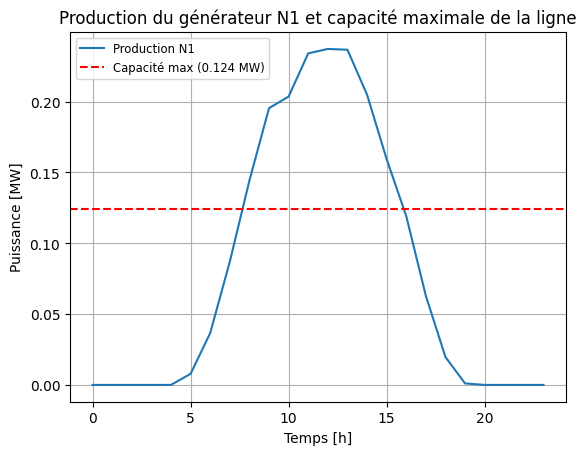

In [408]:
# Charger le fichier Excel
file_path = 'annexes/cases/power_profile_case_5_sum_week.xlsx'

# Charger les données des générateurs (sgen) depuis la feuille 'sgen'
sgen_data = pd.read_excel(file_path, sheet_name='sgen', header=1)

# Extraire la colonne correspondant à la production du générateur N1 (P [MW].2)
n1_data = sgen_data['P [MW].3'].astype(float)

# Convertir les données temporelles en format horaire
time_data = sgen_data['Unnamed: 0']  # La première colonne contient les heures
time_hours = pd.to_datetime(time_data, format='%H:%M:%S').dt.hour + pd.to_datetime(time_data, format='%H:%M:%S').dt.minute / 60.0

# Capacité maximale de la ligne (0.124 MW)
capacity_max = 0.124

# Calcul de l'intégrale totale de la production de N1
total_energy = np.trapz(n1_data, time_hours)

# Calcul de l'intégrale sous la limite de la capacité de la ligne (0.124 MW)
n1_data_clipped = np.clip(n1_data, 0, capacity_max)
energy_below_capacity = np.trapz(n1_data_clipped, time_hours)

# Pertes énergétiques : différence entre l'énergie totale et l'énergie sous la capacité
energy_losses = total_energy - energy_below_capacity

# Affichage des résultats
print(f"Énergie totale produite par N1 (en MW·h) : {total_energy}")
print(f"Énergie injectée sous la capacité maximale de la ligne (en MW·h) : {energy_below_capacity}")
print(f"Pertes énergétiques (en MW·h) : {energy_losses}")

# Tracé de la courbe de production avec la capacité maximale de la ligne
plt.plot(time_hours, n1_data, label="Production N1")
plt.axhline(capacity_max, color='r', linestyle='--', label="Capacité max (0.124 MW)")
plt.xlabel("Temps [h]")
plt.ylabel("Puissance [MW]")
plt.title("Production du générateur N1 et capacité maximale de la ligne")
plt.legend(loc='upper left', bbox_to_anchor=(0, 1), fontsize='small')
plt.grid(True)
plt.show()

# PV futur

In [409]:
print(net_pickle.bus)

            name   type   zone  in_service  vn_kv
0     STMT003438     PQ  Trafo        True   0.42
1     CDBT004764     PQ  North        True   0.42
2     CDBT003746     PQ  North        True   0.42
3     CDBT004760     PQ  North        True   0.42
4     CDBT012139     PQ  North        True   0.42
5     CDBT900784     PQ  North        True   0.42
6     CDBT901452     PQ  South        True   0.42
7     CDBT004774     PQ  South        True   0.42
8     CDBT901604     PQ  South        True   0.42
9     CDBT016055     PQ  South        True   0.42
10            N1     PQ  South        True   0.42
11         60437     PQ  South        True   0.42
12  STMT003438HV  Slack  Trafo        True  18.30


In [416]:
# Supprimer tous les générateurs précédents
net_pickle.sgen.drop(net_pickle.sgen.index, inplace=True)

# Vérification
print(net_pickle.sgen)


# Liste des générateurs et des bus correspondants
generators_info = [
    {"name": "PV_STMT003438", "bus": 0},
    {"name": "PV_CDBT004764", "bus": 1},
    {"name": "PV_CDBT003746", "bus": 2},
    {"name": "PV_CDBT004760", "bus": 3},
    {"name": "PV_CDBT012139", "bus": 4},
    {"name": "PV_CDBT900784", "bus": 5},
    {"name": "PV_CDBT901452", "bus": 6},
    {"name": "PV_CDBT004774", "bus": 7},
    {"name": "PV_CDBT901604", "bus": 8},
    {"name": "PV_CDBT016055", "bus": 9},
    {"name": "PV_N1", "bus": 10},
    {"name": "PV_60437", "bus": 11}
]

# Créer les générateurs (sgen) pour chaque entrée dans la liste
for generator in generators_info:
    pp.create_sgen(
        net=net_pickle,
        bus=generator["bus"],  # Associer le générateur au bus spécifié
        p_mw=0,  # Puissance active initiale à 0
        q_mvar=0,  # Puissance réactive initiale à 0
        name=generator["name"],  # Nom du générateur
        in_service=True  # Générateur en service
    )

# Ajouter un mappage des profils de puissance pour chaque générateur
net_pickle.sgen["profile_mapping"] = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

net_pickle.sgen[["name", "bus", "p_mw", "q_mvar", "in_service"]]


Empty DataFrame
Columns: [name, bus, p_mw, q_mvar, sn_mva, scaling, profile_mapping, type, k, rx, current_source, in_service]
Index: []


,name,bus,p_mw,q_mvar,in_service
0,PV_STMT003438,0,0.0,0.0,True
1,PV_CDBT004764,1,0.0,0.0,True
2,PV_CDBT003746,2,0.0,0.0,True
3,PV_CDBT004760,3,0.0,0.0,True
4,PV_CDBT012139,4,0.0,0.0,True
5,PV_CDBT900784,5,0.0,0.0,True
6,PV_CDBT901452,6,0.0,0.0,True
7,PV_CDBT004774,7,0.0,0.0,True
8,PV_CDBT901604,8,0.0,0.0,True
9,PV_CDBT016055,9,0.0,0.0,True


In [414]:
# Charger le fichier Excel contenant les profils de puissance des générateurs
profile_file_path = "annexes/cases/power_profile_PV_Futur.xlsx"

# Charger les profils de puissance depuis le fichier Excel
time_series: dict = pp_sim.load_power_profile_form_xlsx(file_path=profile_file_path)

# Liste des noms de générateurs et des bus correspondants
generators_info = [
    
    {"name": "PV_STMT003438", "bus": 0},
    {"name": "PV_CDBT004764", "bus": 1},
    {"name": "PV_CDBT003746", "bus": 2},
    {"name": "PV_CDBT004760", "bus": 3},
    {"name": "PV_CDBT012139", "bus": 4},
    {"name": "PV_CDBT900784", "bus": 5},
    {"name": "PV_CDBT901452", "bus": 6},
    {"name": "PV_CDBT004774", "bus": 7},
    {"name": "PV_CDBT901604", "bus": 8},
    {"name": "PV_CDBT016055", "bus": 9},
    {"name": "PV_N1", "bus": 10},  
    {"name": "PV_60437", "bus": 11}  
]

# Création des générateurs (sgen) pour chaque entrée dans la liste
for generator in generators_info:
    pp.create_sgen(
        net=net_pickle,
        bus=generator["bus"],  # Associer le générateur au bus spécifié
        p_mw=0,  # Puissance active initiale à 0
        q_mvar=0,  # Puissance réactive initiale à 0
        name=generator["name"],  # Nom du générateur
        in_service=True  # Générateur en service
    )

# Vérification des générateurs créés
net_pickle.sgen[["name", "bus", "p_mw", "q_mvar", "in_service"]]


pp_sim.apply_power_profile(
    net=net_pickle,
    equipment="sgen",  # Appliquer aux générateurs (sgen)
    power_profiles=time_series["sgen"]  # Les profils de puissance extraits du fichier Excel
)

# Créer un fichier de sortie pour enregistrer les résultats de la simulation
pp_sim.create_output_writer(net=net_pickle)

# Exécuter la simulation et générer les résultats
result_df = pp_sim.run_time_simulation(
    net=net_pickle, output_filename="simulation_results"
)
# Vérifier les données extraites des profils de puissance

# Afficher les résultats de la simulation (par exemple, la tension des bus)
pp_plot.plot_timeseries_result(
    data_df=result_df["res_bus.vm_pu"],
    ylabel="V [pu]",
    plot_title="Bus voltage / Summer week",
    filename="voltage_result",
)




2026-01-22 11:54:33 Sebo pp_heig_simulation[91849] WARNING PV_STMT003438, PV_CDBT004764, PV_CDBT003746, PV_CDBT004760, PV_CDBT012139, PV_CDBT900784, PV_CDBT901452, PV_CDBT004774, PV_CDBT901604, PV_CDBT016055, PV_N1, PV_60437 equipments have no p_mw profiles
2026-01-22 11:54:33 Sebo pp_heig_simulation[91849] WARNING PV_STMT003438, PV_CDBT004764, PV_CDBT003746, PV_CDBT004760, PV_CDBT012139, PV_CDBT900784, PV_CDBT901452, PV_CDBT004774, PV_CDBT901604, PV_CDBT016055, PV_N1, PV_60437 equipments have no q_mvar profiles
2026-01-22 11:54:33 Sebo pandapower.io_utils[91849] INFO Updating output_writer with index 0
/home/sebpfister/rhtlab/.venv/lib/python3.10/site-packages/pandapower/timeseries/output_writer.py:177: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'range(0, 96)' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.



In [417]:
pp_plot.plot_timeseries_result(
    data_df=result_df["res_line.loading_percent"],
    ylabel="[%]",
    plot_title="Line loading / Summer week",
    filename="line_loading_result",
)

In [418]:
for plot_time in [time(hour=8),time(hour=12),time(hour=14),time(hour=17), time(hour=20)]:

    pp_plot.plot_timestamps_powerflow_result(
        net=net_pickle,
        filename="sim_result_" + pp_plot._time_to_str(plot_time),
        plot_time=plot_time,
    )
    print()